<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Modeling Workflow (Walkthrough)

---

### About
Model data from scratch: gather data, clean it, explore it, and then evaluate several models.

### Learning Objectives
- Gather, clean, explore and model a dataset from scratch.
- Split data into testing and training sets using both train/test split and cross-validation and apply both techniques to score a model.
- Evaluate several models.


### Notebook Guide

- Importing libaries
- Load the Data
- Data Cleaning:
     - Initial check
     - Clean up PhD column
     - Clean up Grad.Rate column
     - Clean up Apps column
- Stateless Feature Engineering:
     - Binarize Private column
     - Create a new feature
     - Bin Outstate column
- EDA:
     - Create Histograms of All Numerical Columns
     - Plot a Heatmap of the Correlation Matrix
     - Use seaborn's `.pairplot()` method to create scatterplots
- Model Prep:
     - Create our features matrix (`X`) and target vector (`y`)
     - Train/test split
     - Imputing Missing Values
     - Ordinal Encoding
     - Robust Scaling
     - Instantiate and train our model
- Evaluation
- LINE Assumptions

# Problem Statement
Colleges receive very different numbers of applications, from under 100 at small schools to over 48,000 at large public universities. Admissions offices plan staffing, budgets, marketing and enrollment targets around this number, but it is hard to forecast.

**Problem:** Admissions and planning teams lack a data-driven way to estimate how many applications an institution should expect, or to know which institutional characteristics (size, cost, selectivity, faculty quality, public vs. private) drive application volume.

**Goal:** Build a regression model that predicts the number of applications (`Apps`) a college receives from its known characteristics, using data on 777 U.S. colleges.

# Importing libaries
---

We'll need the following libraries for today's lesson:

1. `pandas`
2. `numpy`
3. `seaborn`
4. `matplotlib.pyplot`
4. `train_test_split` and `cross_val_score` from `sklearn`'s `model_selection` module
5. `LinearRegression` from `sklearn`'s `linear_model` module
6. `StandardScaler` from `sklearn`'s `preprocessing` module
7. `mean_squared_error` from `sklearn`'s `metrics` module

In [60]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import PowerTransformer

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

from sklearn.impute import SimpleImputer

from scipy import stats

from sklearn.model_selection import KFold

# Load the Data

---

Today's [data set](http://www-bcf.usc.edu/~gareth/ISL/data.html) (`College.csv`) is from the [ISLR website](https://cran.r-project.org/web/packages/ISLR/ISLR.pdf) on page 5.

Rename `Unnamed: 0` to `University`.

In [5]:
College_df = pd.read_csv('/content/College.csv')
College_df = College_df.rename(columns={'Unnamed: 0': 'University'})

In [6]:
print(College_df.shape)
College_df.head()

(777, 19)


,University,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


# Data cleaning: Initial check
---

Check the following in the cells below:
1. Do we have any null values?
2. Are any numerical columns being read in as `object`?
3. Any values outside acceptable range?

In [7]:
# 1. Check for nulls
College_df.isnull().sum()

,0
University,0
Private,0
Apps,0
Accept,0
Enroll,0
Top10perc,0
Top25perc,0
F.Undergrad,0
P.Undergrad,0
Outstate,0


In [8]:
# 2. Check column data types
College_df.dtypes

,0
University,object
Private,object
Apps,int64
Accept,int64
Enroll,int64
Top10perc,int64
Top25perc,int64
F.Undergrad,int64
P.Undergrad,int64
Outstate,int64


In [9]:
# 3. Check summary statistics
College_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Apps,777.0,3001.638353,3870.201484,81.0,776.0,1558.0,3624.0,48094.0
Accept,777.0,2018.804376,2451.113971,72.0,604.0,1110.0,2424.0,26330.0
Enroll,777.0,779.972973,929.176190,35.0,242.0,434.0,902.0,6392.0
Top10perc,777.0,27.558559,17.640364,1.0,15.0,23.0,35.0,96.0
Top25perc,777.0,55.796654,19.804778,9.0,41.0,54.0,69.0,100.0
F.Undergrad,777.0,3699.907336,4850.420531,139.0,992.0,1707.0,4005.0,31643.0
P.Undergrad,777.0,855.298584,1522.431887,1.0,95.0,353.0,967.0,21836.0
Outstate,777.0,10440.669241,4023.016484,2340.0,7320.0,9990.0,12925.0,21700.0
Room.Board,777.0,4357.526384,1096.696416,1780.0,3597.0,4200.0,5050.0,8124.0
Books,777.0,549.380952,165.105360,96.0,470.0,500.0,600.0,2340.0


**Answer:** Yes, there are outliers (Rutgers at New Brunswick, Purdue, Boston University, ...).

They are large public universities with genuinely huge applicant pools, and every related column (`Accept`, `Enroll`, `F.Undergrad`) is consistent with them.

They are valid data, not errors, so we keep them and handle the skew with robust scaling and a log transform instead of deleting rows.

In [10]:
print(f"{"PhD"}: {College_df['PhD'].unique()}")

PhD: ['70' '29' '53' '92' '76' '?' '90' '89' '79' '40' '82' '73' '60' '36' '78'
 '48' '62' '69' '83' '55' '88' '57' '93' '85' '65' '66' '81' '59' '58'
 '68' '98' '71' '74' '61' '35' '87' '80' '63' '75' '39' '99' '100' '95'
 '77' '72' '64' '10' '86' '22' '50' '41' '8' '67' '94' '56' '46' '54' '84'
 '97' '51' '42' '49' '52' '43' '37' '45' '47' '91' '31' '96' '34' '33'
 '44' '32' '14' '103' '26' '16']


**Findings from the initial check**
1. No `NaN`s reported... but that's misleading: `PhD` hides missing values as the string `'?'`.
2. `PhD` is read as `object` (string) because of those `'?'` entries.
3. Out-of-range values: `Grad.Rate` max is **118** (a rate can't exceed 100%). `PhD` (once numeric) also has a value of **103**. `Apps` has a big right tail (max 48,094) that needs checking.

# Data cleaning: Clean up `PhD` column
---

`PhD` is being read in as a string because some of the cells contain non-numerical values.

In the cell below:
1. replace any non-numerical values with `NaN`'s
2. change the column datatype to float
3. Verify the number of missing values

In [11]:
# 1. and 2.
College_df['PhD'] = pd.to_numeric(College_df['PhD'], errors='coerce') # '?' ---> 'NAN'
College_df['PhD'].dtype

dtype('float64')

In [12]:
# 3.
College_df['PhD'].isnull().sum()

np.int64(29)

`PhD` should now contain missing values.

1. Suggest a strategy to deal with it.

**NOTE**: If you decide to substitute with plausible values, DO NOT APPLY IT YET HERE.

In [13]:
# Your suggestions
# 29 of 777 rows (~3.7%) are missing -> too many to drop, and PhD is a useful predictor.

# Strategy: impute with the MEDIAN (robust to skew; PhD is left-skewed).

# Do it AFTER the train/test split, fitting the imputer on X_train only, to avoid data leakage.

print('Missing PhD: {:.1%}'.format(College_df['PhD'].isnull().mean()))

Missing PhD: 3.7%


We weren't able to describe `PhD` using summary statistics as its type was `ogject`

1. Apply `.describe()` to the column
2. Any values out of normal range?
3. Suggest a strategy to fix the errors, if any.

In [14]:
# 1.
College_df['PhD'].describe()

,PhD
count,748.000000
mean,72.518717
std,16.315199
min,8.000000
25%,62.000000
50%,75.000000
75%,85.000000
max,103.000000


In [15]:
# 2.
# A percentage of faculty with PhDs cannot exceed 100
College_df[College_df['PhD'] > 100][['University', 'PhD', 'Terminal']]

,University,PhD,Terminal
582,Texas A&M University at Galveston,103.0,88


In [16]:
# 3.
# One row (Texas A&M Galveston, PhD=103 > 100) is impossible and we can't know the true value,

# so treat it as missing (NaN) and let the imputer handle it after the split.

College_df.loc[College_df['PhD'] > 100, 'PhD'] = np.nan
print(College_df['PhD'].max(), College_df['PhD'].isnull().sum())

100.0 30


Strategy: an impossible value is just another missing value, so replace it with `NaN` now (stateless) and impute later using training data only. `PhD` now has **30** missing values (29 `?` + the 103).

# Data cleaning: Clean up `Grad.Rate` column
---

`Grad.Rate` is the graduation rate, but it has data entry errors.

1. Suggest a strategy to fix the errors and apply it

_HINT: check the rows where the errors take place_

In [17]:
# Look at the rows with errors
College_df[College_df['Grad.Rate'] > 100][['University', 'Private', 'Grad.Rate']]

,University,Private,Grad.Rate
95,Cazenovia College,Yes,118


In [18]:
# Only one impossible value (Cazenovia College, 118%). We can't tell the true value (typo for 18? 100?),
# so set it to NaN and impute later with the train median.

College_df.loc[College_df['Grad.Rate'] > 100, 'Grad.Rate'] = np.nan

In [19]:
College_df['Grad.Rate'].describe()

,Grad.Rate
count,776.000000
mean,65.395619
std,17.084743
min,10.000000
25%,53.000000
50%,65.000000
75%,78.000000
max,100.000000


# Data cleaning: Clean up `Apps` column
---

1. Are there any outliers in the `Apps` column? Can you safely remove any?

In [20]:
College_df.sort_values('Apps', ascending=False)[['University', 'Apps', 'Accept', 'Enroll', 'F.Undergrad']].head(8)

,University,Apps,Accept,Enroll,F.Undergrad
483,Rutgers at New Brunswick,48094,26330,4520,21401
461,Purdue University at West Lafayette,21804,18744,5874,26213
59,Boston University,20192,13007,3810,14971
605,University of California at Berkeley,19873,8252,3215,19532
445,Pennsylvania State Univ. Main Campus,19315,10344,3450,28938
637,University of Michigan at Ann Arbor,19152,12940,4893,22045
366,Michigan State University,18114,15096,6180,26640
274,Indiana University at Bloomington,16587,13243,5873,24763


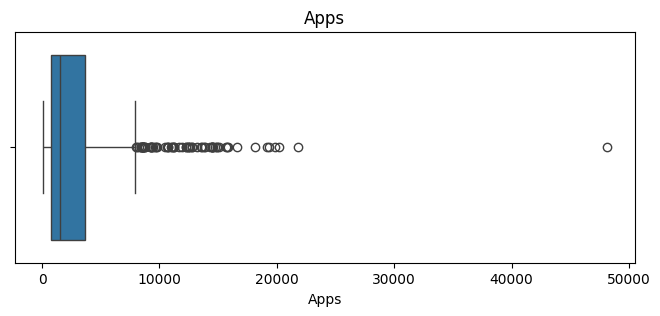

In [21]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=College_df['Apps'])
plt.title('Apps')
plt.show()

In [22]:
# Rutgers (48,094) is far above the rest but it is a REAL, internally consistent record
# (Accept/Enroll/F.Undergrad are all the largest too). Do NOT remove it.
# Instead handle the skew with a robust scaler / log transform.
College_df[['Apps', 'Accept', 'Enroll']].describe().T

,count,mean,std,min,25%,50%,75%,max
Apps,777.0,3001.638353,3870.201484,81.0,776.0,1558.0,3624.0,48094.0
Accept,777.0,2018.804376,2451.113971,72.0,604.0,1110.0,2424.0,26330.0
Enroll,777.0,779.972973,929.176190,35.0,242.0,434.0,902.0,6392.0


# Stateless Feature Engineering: Binarize `Private` column
---

In the cells below, convert the `Private` column into numerical values.

In [23]:
College_df['Private'] = College_df['Private'].map({'Yes': 1, 'No': 0})

In [24]:
College_df['Private'].value_counts()

,count
Private,
1,565
0,212


# Stateless Feature Engineering: Create a new feature
---

An acceptance rate is more meaningful than the counts of applicants and accepted students on their own. It represents the proportion of applicants who were accepted.

1. Create a new feature `Accept.Rate` and save it back to our dataframe

In [25]:
College_df['Accept.Rate'] = College_df['Accept'] / College_df['Apps']
College_df['Accept.Rate'].describe()

,Accept.Rate
count,777.000000
mean,0.746928
std,0.147104
min,0.154486
25%,0.675647
50%,0.778750
75%,0.848522
max,1.000000


# Stateless Feature Engineering: Bin `Outstate ` column
---

1. Create a new column `Outstate.Tier` to split out-of-state tuition into bins. Use the following thresholds:
- 0 - 8,000: Low
- 8,000 - 12,000: Medium
- 12,000 - 16,000: High
- 16,000 and up: Very High



In [26]:
bins = [0, 8000, 12000, 16000, np.inf]

labels = ['Low', 'Medium', 'High', 'Very High']

College_df['Outstate.Tier'] = pd.cut(
                                      College_df['Outstate'],
                                      bins=bins,
                                      labels=labels,
                                      right=False).astype(object)
College_df['Outstate.Tier'].value_counts()

,count
Outstate.Tier,
Medium,294
Low,241
High,150
Very High,92


# EDA: Create Histograms of All Numerical Columns
---

1. Which features would you apply a standard scaling? Robust scaling?
2. Which features would you apply Log Transformation?

In [27]:
num_cols = College_df.select_dtypes('number').columns
num_cols

Index(['Private', 'Apps', 'Accept', 'Enroll', 'Top10perc', 'Top25perc',
       'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board', 'Books',
       'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni', 'Expend',
       'Grad.Rate', 'Accept.Rate'],
      dtype='object')

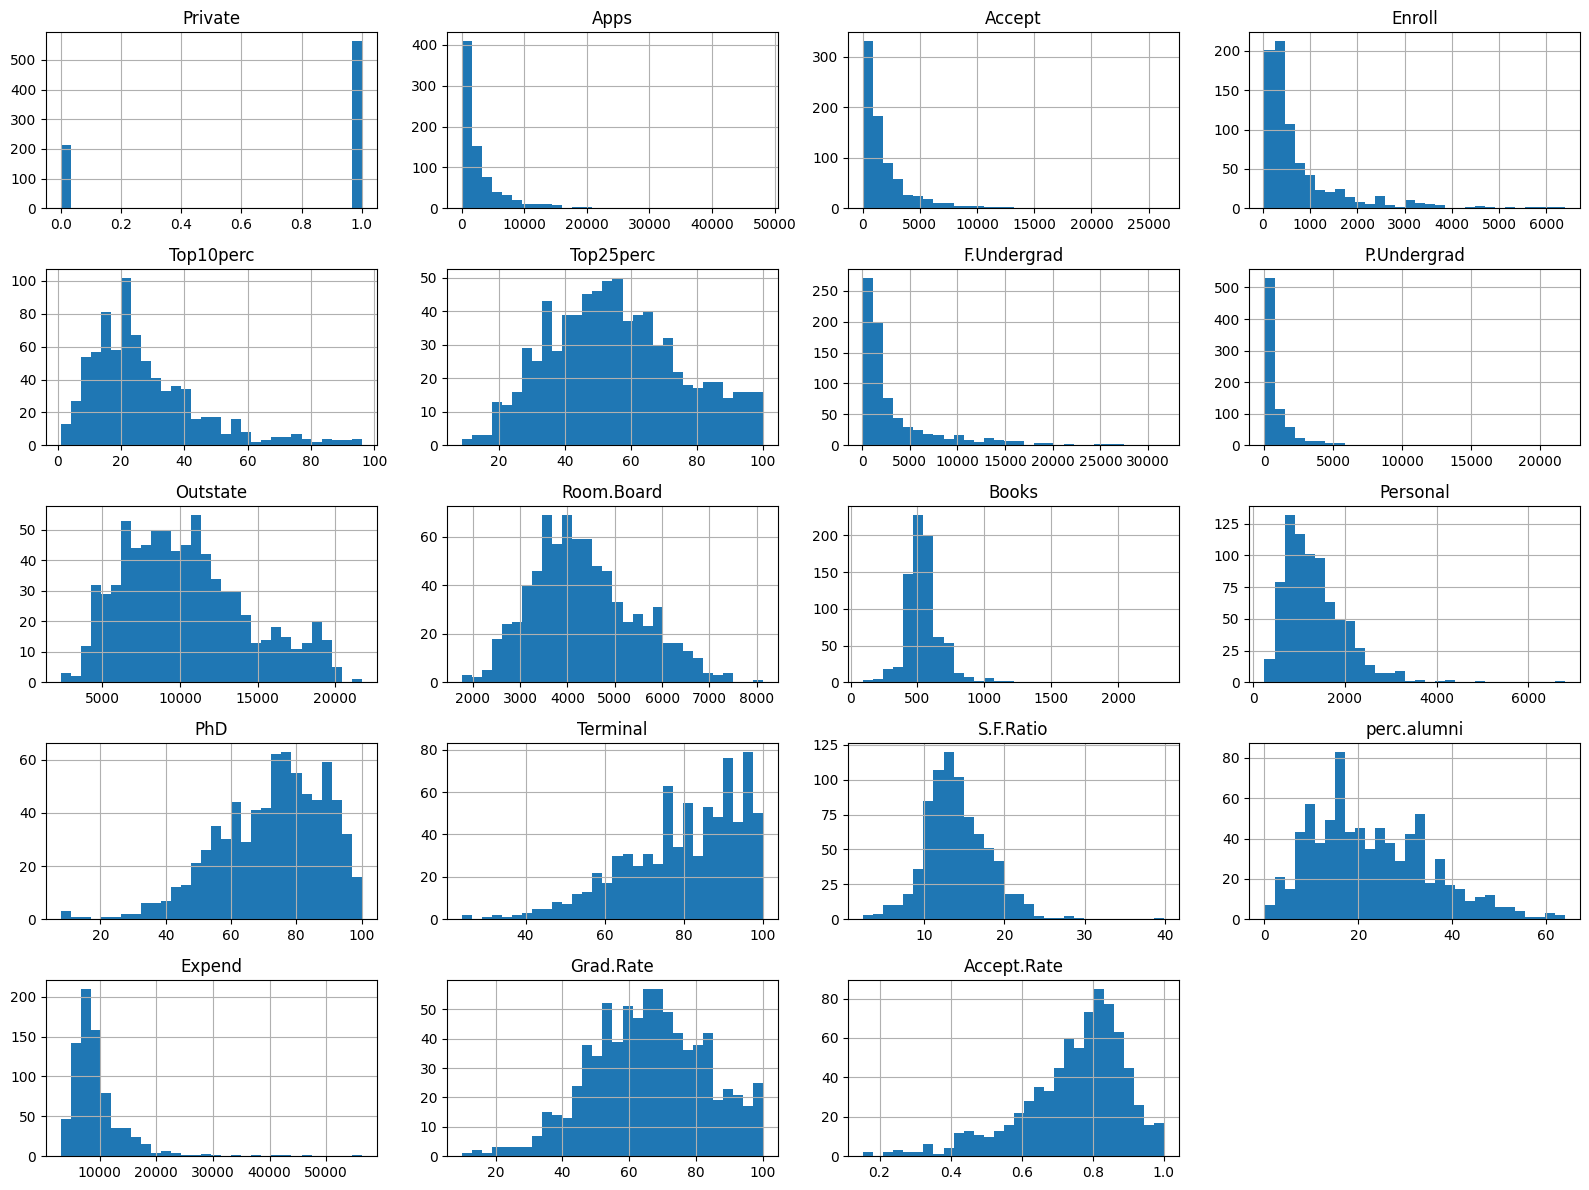

In [28]:
College_df[num_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

In [29]:
College_df[num_cols].skew().sort_values()

,0
Accept.Rate,-1.068202
Private,-1.021933
Terminal,-0.816542
PhD,-0.761612
Grad.Rate,-0.141492
Top25perc,0.259340
Room.Board,0.477356
Outstate,0.509278
perc.alumni,0.606891
S.F.Ratio,0.667435


**1. Scaling**
- **StandardScaler** (roughly symmetric, few outliers): `Top25perc`, `Room.Board`, `Outstate`, `S.F.Ratio`, `Grad.Rate`, `perc.alumni`, `Terminal`, `PhD`.
- **RobustScaler** (skewed / heavy outliers): `Apps`, `Accept`, `Enroll`, `F.Undergrad`, `P.Undergrad`, `Expend`, `Books`, `Personal`, `Top10perc`.

**2. Log transformation** (strong right skew, skew > ~2): `Apps` (target), `Accept`, `Enroll`, `F.Undergrad`, `P.Undergrad`, `Expend`, `Books`, `Personal`.

# EDA: Plot a Heatmap of the Correlation Matrix
---

Heatmaps are an effective way to visually examine the correlational structure of your predictors.

1. Plot a heatmap
2. What features are highly correlated with each other? (use >=0.8 threshold value)
3. Any features leading to future/target-related leakage ?
4. Make a list of other features you recommend to drop based on the correlation value.

**NOTE**: Don't drop any column now, just make a list of features you plan not to use.

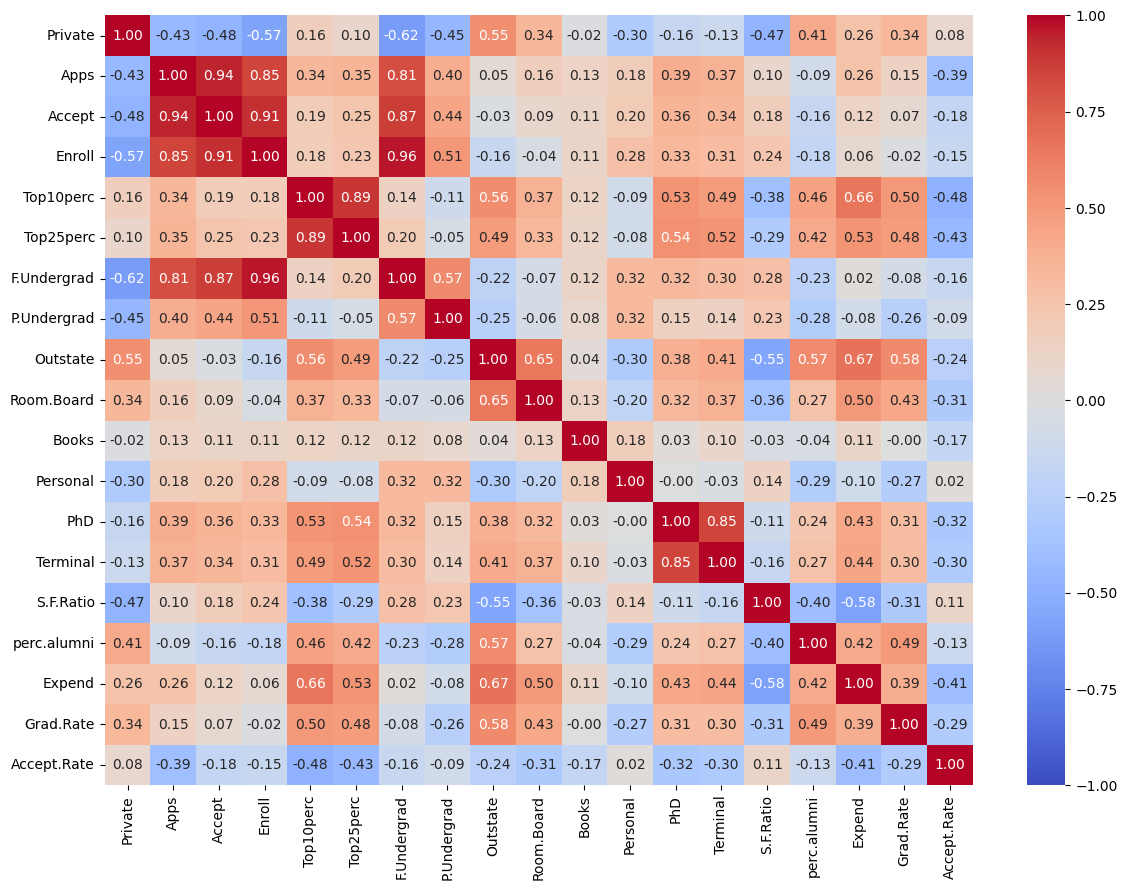

In [30]:
# 1.
corr = College_df.select_dtypes('number').corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.show()

In [31]:
# 2.find pairs of features that are highly correlated (|corr| >= 0.8).

# 1. Build a mask that keeps only the upper triangle of the correlation matrix
#    (the matrix is symmetric, so this avoids duplicate pairs and the diagonal where a column correlates 1.0 with itself).
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)

# 2. Take the absolute values (a strong negative correlation is also a problem),
#    apply the mask, and turn the table into a list of pairs.
pairs = corr.abs().where(mask).stack()

# 3. Keep only the pairs with correlation >= 0.8, sorted from strongest to weakest.
pairs[pairs >= 0.8].sort_values(ascending=False)

Enroll     F.Undergrad    0.964640
Apps       Accept         0.943451
Accept     Enroll         0.911637
Top10perc  Top25perc      0.891995
Accept     F.Undergrad    0.874223
PhD        Terminal       0.848205
Apps       Enroll         0.846822
           F.Undergrad    0.814491
dtype: float64

In [32]:
# 3. Leakage
# Accept and Enroll happen AFTER a student applies (they are outcomes of the application count),
# and Accept.Rate = Accept / Apps is built directly from the target.

# None of them would be known before the number of applications is known.

print('Correlation with target:')
print(corr.loc[['Accept', 'Enroll', 'Accept.Rate'], 'Apps'].round(3))

Correlation with target:
Accept         0.943
Enroll         0.847
Accept.Rate   -0.393
Name: Apps, dtype: float64


In [33]:
# 4. Features we plan NOT to use
drop_cols = [
    'University',   # identifier, not a feature
    'Accept',       # leakage (r=0.94 with Apps)
    'Enroll',       # leakage; also r=0.97 with F.Undergrad
    'Accept.Rate',  # leakage: computed from the target
    'Top25perc',    # r=0.89 with Top10perc -> keep one
    'Terminal',     # r=0.85 with PhD -> keep one
    'Outstate',     # replaced by Outstate.Tier (ordinal)
]
drop_cols

['University',
 'Accept',
 'Enroll',
 'Accept.Rate',
 'Top25perc',
 'Terminal',
 'Outstate']

##### What if I just wanted to look at the correlation to `apps`?

In [34]:
corr['Apps'].drop('Apps').sort_values(ascending=False)

,Apps
Accept,0.943451
Enroll,0.846822
F.Undergrad,0.814491
P.Undergrad,0.398264
PhD,0.391922
Terminal,0.369491
Top25perc,0.351640
Top10perc,0.338834
Expend,0.259592
Personal,0.178731


# EDA: Use seaborn's `.pairplot()` method to create scatterplots
---

1. Let's create a pairplot to see how some of our stronger predictors correlate to our target (`apps`).

**HINT**: Instead of creating a pairplot of the entire DataFrame, we can use the `y_vars` and `x_vars` params to get a smaller subset.

2. Do you seen any linear relation between features and target? What transformation you recomment here?

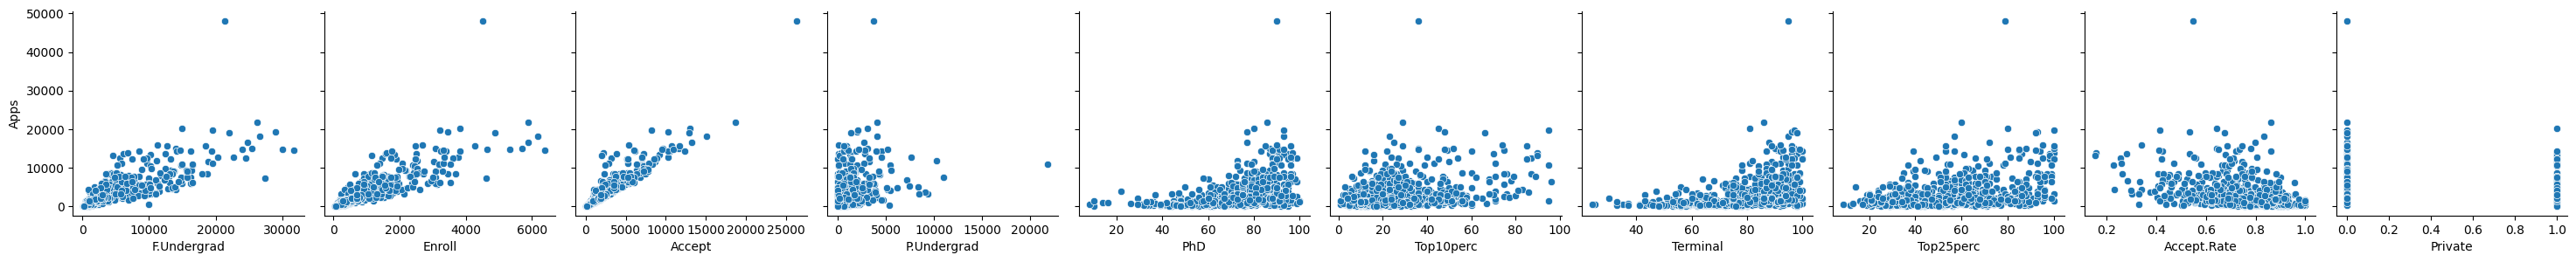

In [35]:
# 1.
strong = ['F.Undergrad', 'Enroll', 'Accept', 'P.Undergrad', 'PhD', 'Top10perc', 'Terminal','Top25perc','Accept.Rate' , 'Private']
sns.pairplot(College_df, x_vars=strong, y_vars=['Apps'], height=3)
plt.show()

In [36]:
# 2.

# F.Undergrad, Enroll and Accept show a clear positive, roughly linear relationship with Apps,

#but the spread fans out as values grow (heteroscedasticity) and a few huge schools dominate.
# Features and target are right-skewed -> recommend log (or Yeo-Johnson power) transform on Apps
# and skewed features (F.Undergrad, P.Undergrad, ...) to linearize and stabilize the variance.

# Model_1 Prep: Create our features matrix (`X`) and target vector (`y`)
---

What should our features be?

The `apps` column is our label: the number of applications received by that university.

In the cell below, create your `X` and `y` variables.

In [37]:
X = College_df.drop(columns=['Apps'] + drop_cols)
y = College_df['Apps']
print(X.columns.tolist())
X.shape

['Private', 'Top10perc', 'F.Undergrad', 'P.Undergrad', 'Room.Board', 'Books', 'Personal', 'PhD', 'S.F.Ratio', 'perc.alumni', 'Expend', 'Grad.Rate', 'Outstate.Tier']


(777, 13)

# Model_1 Prep: Train/test split
---

We always want to have a holdout set to test our model. Use the `train_test_split` function to split our `X` and `y` variables into a training set and a holdout set.

**HINT**: We have less than 1000 samples. Think of a suitable test size

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(621, 13) (156, 13)


# Model_1 Prep: Imputing Missing Values
---

Some machine learning models cannot work with missing values (`NaN`), so we need to replace them before training.

An **imputer** fills missing values using a value learned from the data. For numerical features, a common approach is to replace missing values with the **mean** or **median**.

⚠️ **Why do we impute after the train/test split?**

The median/mean is calculated from the data. If we calculate it using the full dataset, information from the test set would leak into the training process.

Therefore:

- Fit the imputer using **`X_train` only**
- Use that same imputer to transform both **`X_train` and `X_test`**

Check this [doc](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) for more details

In the cell below:

1. Identify the numerical features containing missing values. Save them in a list
2. Instantiate a `SimpleImputer` using `strategy="median"`.
3. Fit the imputer on the training features containing missing values.
4. Transform both the training and test data ( Save the results back to **`X_train` and `X_test`**)

In [39]:
# 1.
cols_impute = X_train.columns[X_train.isnull().any()].tolist()
print(cols_impute)
X_train[cols_impute].isnull().sum()

['PhD', 'Grad.Rate']


,0
PhD,24
Grad.Rate,1


In [40]:
# 2.
imputer = SimpleImputer(strategy='median')

In [41]:
# 3.
imputer.fit(X_train[cols_impute])

SimpleImputer(strategy='median')

In [59]:
# 4.
X_train[cols_impute] = imputer.transform(X_train[cols_impute])

X_test[cols_impute] = imputer.transform(X_test[cols_impute])

print(X_train.isnull().sum().sum(), X_test.isnull().sum().sum())

0 0


# Model_1 Prep: Ordinal Encoding
---

In the cell below:

1. Identify the ordinal categorical features. Save them in a list
2. Instantiate the appropriate transformer
3. Fit the transformer on the training features containing missing values.
4. Transform both the training and test data ( Save the results back to **`X_train` and `X_test`**)

In [43]:
# 1.
cols_ordinal = ['Outstate.Tier']

In [44]:
# 2.
ord_enc = OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']])

In [45]:
# 3.
ord_enc.fit(X_train[cols_ordinal])

OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']])

In [46]:
# 4.
X_train[cols_ordinal] = ord_enc.transform(X_train[cols_ordinal])

X_test[cols_ordinal] = ord_enc.transform(X_test[cols_ordinal])

X_train[cols_ordinal].value_counts().sort_index()

,count
Outstate.Tier,
0.0,190
1.0,234
2.0,121
3.0,76


# Model_1 Prep: Robust Scaling
---

In the cell below:
1. Select the features to scale. Save them in a variable
2. Fit a `RobustScaler` to `X_train` and
3. Use it to transform both `X_train` and `X_test`.

**NOTE**: In real projects, we usually apply different scales based on the data distribution. For the sake of practice, we are just choosing one for all features

In [47]:
# 1.
cls_num = [c for c in X_train.columns if c not in ['Private'] + cols_ordinal]
cls_num

['Top10perc',
 'F.Undergrad',
 'P.Undergrad',
 'Room.Board',
 'Books',
 'Personal',
 'PhD',
 'S.F.Ratio',
 'perc.alumni',
 'Expend',
 'Grad.Rate']

In [48]:
# 2.
scaler = RobustScaler()
scaler.fit(X_train[cls_num])

RobustScaler()

In [49]:
# 3.
X_train[cls_num] = scaler.transform(X_train[cls_num])

X_test[cls_num] = scaler.transform(X_test[cls_num])
X_train.head()

,Private,Top10perc,F.Undergrad,P.Undergrad,Room.Board,Books,Personal,PhD,S.F.Ratio,perc.alumni,Expend,Grad.Rate,Outstate.Tier
739,0,-0.55,0.159123,-0.133333,-0.872483,0.666667,0.0125,-1.826087,0.571429,-0.611111,-1.042161,-0.192308,0.0
133,1,0.00,0.003536,0.646784,0.990604,2.000000,0.3750,-0.391304,0.163265,0.388889,-0.578894,-0.038462,1.0
234,1,-0.80,-0.404173,-0.349708,-1.000000,-0.666667,-0.4375,0.086957,0.102041,0.166667,-0.480182,0.423077,1.0
55,1,0.10,-0.448020,-0.367251,-1.000000,0.000000,-0.2500,0.043478,0.163265,1.777778,0.000000,-0.538462,0.0
639,0,1.65,0.055870,-0.218713,-0.677852,0.666667,0.3750,-0.043478,0.224490,-0.277778,-0.419339,-0.538462,1.0


# Model_1 Prep: Instantiate and train our model
---


In [50]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
pd.Series(lr_model.coef_, index=X_train.columns).sort_values()

,0
Private,-533.722475
perc.alumni,-474.329654
P.Undergrad,-178.078365
PhD,-168.975434
Personal,-128.288756
Outstate.Tier,-79.885564
Books,18.414617
S.F.Ratio,71.577000
Expend,369.998963
Top10perc,424.726330


**Main drivers of applications**
- **`F.Undergrad` (+1953.61):** the strongest driver. Larger schools
 whit Number of fulltime undergraduates receive far more applications.
- **`Grad.Rate` (+725.67), `Room.Board` (+657.31), `Top10perc` (+424.73), `Expend` (+370.00):** moderate positive effects.
- **`Private` (-533.72):** private schools get about 534 fewer applications than similar public schools.
- **`perc.alumni` (-474.33):** a higher alumni-donation share goes with fewer applications, likely because those schools are smaller and older.
- **`P.Undergrad` (-178.08), `PhD` (-168.98), `Personal` (-128.29), `Outstate.Tier` (-79.89):** small negative effects.
- **`S.F.Ratio` (+71.58), `Books` (+18.41):** close to zero.


# Model_1 Evaluation
---

Use `MAE` to evaluate the model.

1. Calculate the training MAE
2. Calculate the testing MAE
3. Do you think we are overfitting, underfitting?

In [51]:
# 1.
y_train_pred = lr_model.predict(X_train)
train_mae = mean_absolute_error(y_train, y_train_pred)
print(f'Train MAE: {train_mae:,.0f}')

Train MAE: 1,041


In [52]:
# 2.
y_test_pred = lr_model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_test_pred)
print(f'Test MAE:  {test_mae:,.0f}')
print(f'Test RMSE: {root_mean_squared_error(y_test, y_test_pred):,.0f}')
print(f'Baseline MAE (predict train mean): {mean_absolute_error(y_test, np.full(len(y_test), y_train.mean())):,.0f}')

Test MAE:  1,122
Test RMSE: 1,703
Baseline MAE (predict train mean): 2,580


In [53]:
# 3.
# Train and test MAE are of similar size (no large gap), so the model is NOT overfitting.

# The model does learn signal (test MAE ~1,122 vs ~2,580 for always predicting the mean)

print('Gap (test - train):', round(test_mae - train_mae))

Gap (test - train): 82


---

In [54]:
# 5-fold cross-validation on the TRAINING set only (the test set stays untouched)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = -cross_val_score(lr_model, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')

print('MAE per fold:', cv_scores.round(0))
print(f'Mean CV MAE: {cv_scores.mean():,.0f}  (std: {cv_scores.std():,.0f})')
print(f'Train MAE:   {train_mae:,.0f}')
print(f'Test MAE:    {test_mae:,.0f}')

MAE per fold: [1334.  933. 1090. 1043.  996.]
Mean CV MAE: 1,079  (std: 137)
Train MAE:   1,041
Test MAE:    1,122


**Cross-validation result**
- Mean CV MAE (≈ 1,079) is close to the train MAE (≈ 1,041) and the test MAE (≈ 1,122), so the model's performance is stable and not just lucky on one split.
- The fold scores range from ≈ 933 to ≈ 1,334 (std ≈ 137).

- *Note:* the imputer and scaler were fit on all of `X_train` before the CV, so each fold has a very small amount of leakage.

# Model_1 LINE Assumptions
---

1. Check the distribution of your errors
2. Check the equality of variace for your error

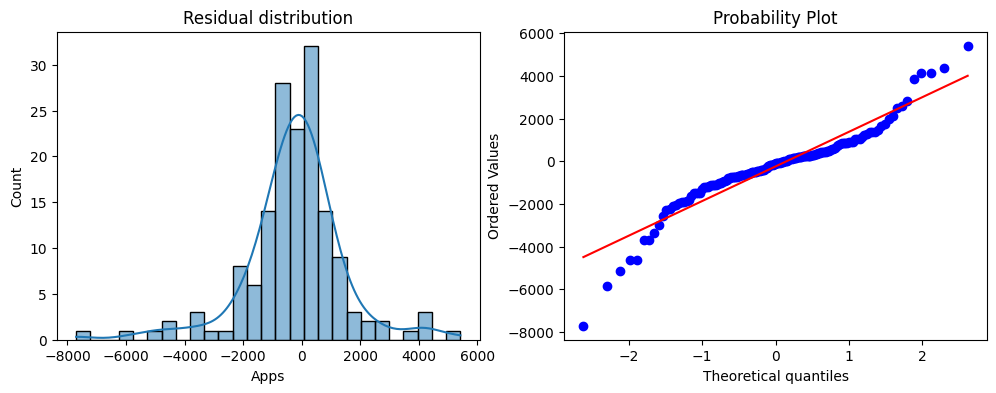

In [55]:
# N - Normality of errors
residuals = y_test - y_test_pred
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(residuals, kde=True, ax=ax[0]); ax[0].set_title('Residual distribution')

stats.probplot(residuals, dist='norm', plot=ax[1])
plt.show()

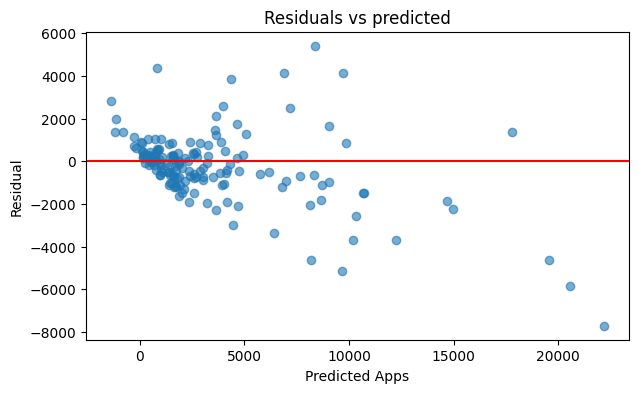

In [56]:
# E - Equal variance of errors
plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red')
plt.xlabel('Predicted Apps'); plt.ylabel('Residual')
plt.title('Residuals vs predicted')
plt.show()

> Variance of the dependent variable varies and is not constant across the entire dataset.

**LINE check:**
- **N (normality):** residuals are heavy-tailed
- **E (equal variance):** the residual spread widens as predictions grow (heteroscedasticity). The model even predicts negative applications for a few schools.


# Model_2 Recommendations
---

We could now apply power transformations for the extremely skewed features/target and test if we get better results.

We will come back to this notebook after we introduce pipelines